# Business Questions

**Dataset**: UK gift shop transactions, 2010–2011.

**Business Questions**:
1. Which products are most popular by quantity sold?
2. Which countries generate the most revenue?

**Useful for**: Shop owner and marketing team to improve sales strategy.

# 01 Load_Cleaning_Preprocessing

Goal: Load data, identify and fix data issues

### Loading

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
e_co_raw_df = pd.read_csv('../data/e-commerce.csv', encoding='latin-1')


### Preprocessing

In [245]:
#Changing the datatype of InvoiceDate from string to usable datetime format
df=e_co_raw_df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month

In [246]:
df['Revenue']=df['Quantity']*df['UnitPrice']

### Identifying Issues 

In [247]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34


Obeservation 1: 84029* variants differ in suffix only — not product variants. description.

Action 1: Prioritize other cleaning issues first 

In [248]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Month,Revenue
count,541909.000000,541909,541909.000000,406829.000000,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,7.553128,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,1.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,5.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,8.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,11.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,12.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,3.509055,378.810824


Observation 1: Quantity and UnitPrice contain negative values 
               and extreme outliers.

Action 1: Filter out negative Quantity and UnitPrice 
          (likely returns/errors) during Cleaning.

Action 2: Note outliers — investigate later if they 
          affect analysis results.

In [249]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   Month        541909 non-null  int32         
 9   Revenue      541909 non-null  float64       
dtypes: datetime64[us](1), float64(3), int32(1), int64(1), str(4)
memory usage: 39.3 MB


Logic problem !
Now checking all the code logic
Does jupyter has a debug mode?

Observation 1: CustomerID has missing values.

Action 1: Explore missing customer patterns before cleaning.

Observation 2: Description has missing values.

Action 1: Explore missing product patterns before cleaning.

Observation 3: InvoiceDate is not datetime.

Action 1: Convert before time analysis.

In [250]:
# To view whether how long does the record spans
df['InvoiceDate'].agg(['min', 'max'])

min   2010-12-01 08:26:00
max   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[us]

In [251]:
print(e_co_raw_df.shape)  # 應該是 (541909, 8)
print(df.shape)

(541909, 8)
(541909, 10)


### Cleaning

Since the project's aim is not calculating the return rate of a product and identify reasons of return.

We will remove or the negative values 

In [252]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] >= 0)]

In [253]:
df_clean.shape

(531283, 10)

In [254]:
# Calculating and comparing the missing ratio of CustomerID and Description respectively
Missing_ratio_CustomerID=(df_clean['CustomerID'].isna().sum())/len(df_clean['CustomerID'])
Missing_ratio_Description=(df_clean['Description'].isna().sum())/len(df_clean['Description'])
print("The missing report:")
print(f"The number of missing records of CustomerID: {df_clean['CustomerID'].isna().sum()}")
print(f"The number of missing records of Description: {df_clean['Description'].isna().sum()}")
print()

print(f'The percentage of missing CustomerID: {Missing_ratio_CustomerID*100}')
print(f'The percentage of missing Description: {Missing_ratio_Description*100}')

The missing report:
The number of missing records of CustomerID: 133359
The number of missing records of Description: 592

The percentage of missing CustomerID: 25.101311353835904
The percentage of missing Description: 0.11142837244933491


Observation 1: ~25% CustomerID missing 

Action 1: Filter and inspect patterns

Action 2: Compare later only if the missing group shows a clear clue.

Observation 2: ~0.111% Description missing

Actions: Same approach as observation 1

#### CustomerID_NaN

In [255]:
#Filtering out all the 'CustomerID' missing records in.
CustomerID_NaN=df_clean[df_clean['CustomerID'].isna()]
CustomerID_NaN.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,12,0.00
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,12,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,12,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,12,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,12,3.32


Obeservation 1: The first record have both description and customerID as NaN. Whereas unitprice is 0.0.

Action 1: Identify if missing rows of description is the subset of missing rows of CustomerID

Observation 2: The 5 records are on the same day

Action 1: Make a line chart of months especially december.


##### Figure 1: "Top 5 invoice count for missing CustomerID"

Text(0, 0.5, 'Number of Invoices')

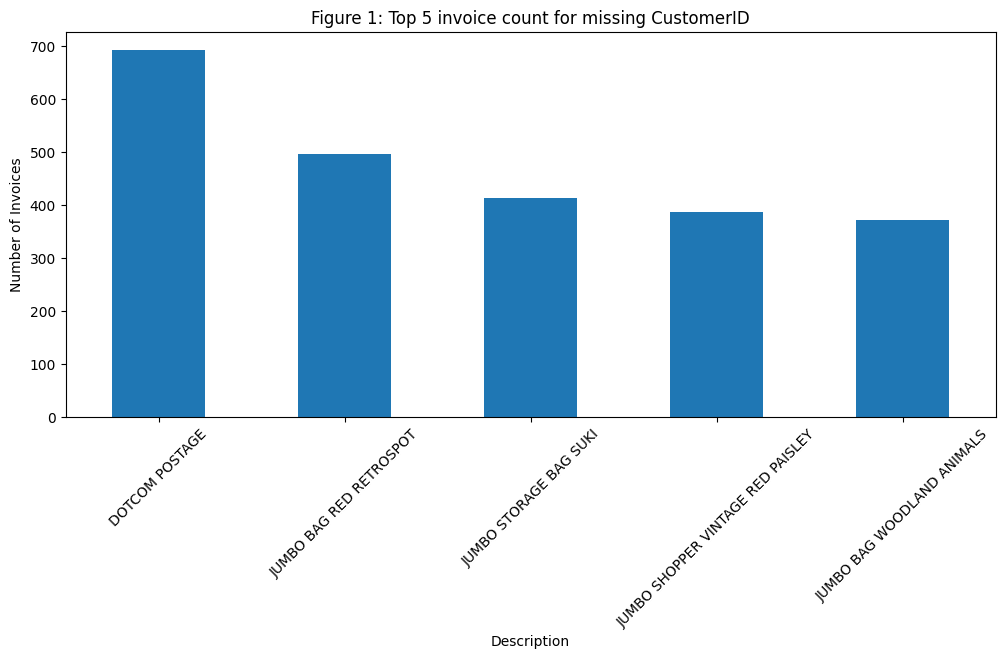

In [256]:
plt.figure(figsize=(12, 5))
plt.tight_layout()

CustomerID_NaN['Description'].value_counts().sort_values(ascending=False).head().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Figure 1: Top 5 invoice count for missing CustomerID")
plt.xlabel("Description")
plt.ylabel("Number of Invoices")

Observation 1: The brand "JUMBO" has occupied 4 seats of the top 5 records

action 1: See whether Jumbo brand has the highest number of rows in CustomerID_NaN.

Obeservation 2: DOTCOM POSTAGE is most popular 

action 1: calculate the number of invoice of DOtcom against total missing records

In [257]:
dotcom_over_total=len(CustomerID_NaN[CustomerID_NaN['Description']=='DOTCOM POSTAGE'])/len(CustomerID_NaN)
print(f' The percentage of records that DOTCOM POSTAGE has occcupied {dotcom_over_total*100} percent')

 The percentage of records that DOTCOM POSTAGE has occcupied 0.5189001117284923 percent


Obeservation 1: DOTCOM POSTAGE is most popular but does not occupy high percentage in missing records.

action 1: Calculate the number of invoice of DOTCOM against total missing records

In [258]:
print(f'The mean, median and standard deviation of number of records in each product/ description')
print(f'The mean: {CustomerID_NaN['Description'].value_counts().mean()}')
print(f'The median: {CustomerID_NaN['Description'].value_counts().median()}')
print(f'The standard deviation {CustomerID_NaN['Description'].value_counts().std()}')


The mean, median and standard deviation of number of records in each product/ description
The mean: 38.786736780601814
The median: 22.0
The standard deviation 50.08958169698712


Observation 1: Highly right skewed as std > mean and mean > median

action 1: identify and decision to clean outliers

In [259]:
No_Jumbo_records=len(CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')])

print(f'The percentage of number of JUMBO products {No_Jumbo_records/len(CustomerID_NaN)*100}')

The percentage of number of JUMBO products 4.0499703807017156


Obeservation: JUMBO brand does not occupies most records in the number of records.

##### Analyzing the most popular products and brand occupy by quantity instead of number of records

In [260]:
Description_Quantity=CustomerID_NaN.groupby('Description')['Quantity'].sum()

In [261]:
Description_Quantity=Description_Quantity.sort_values(ascending=False)

##### Comparison between figure 1 and 2

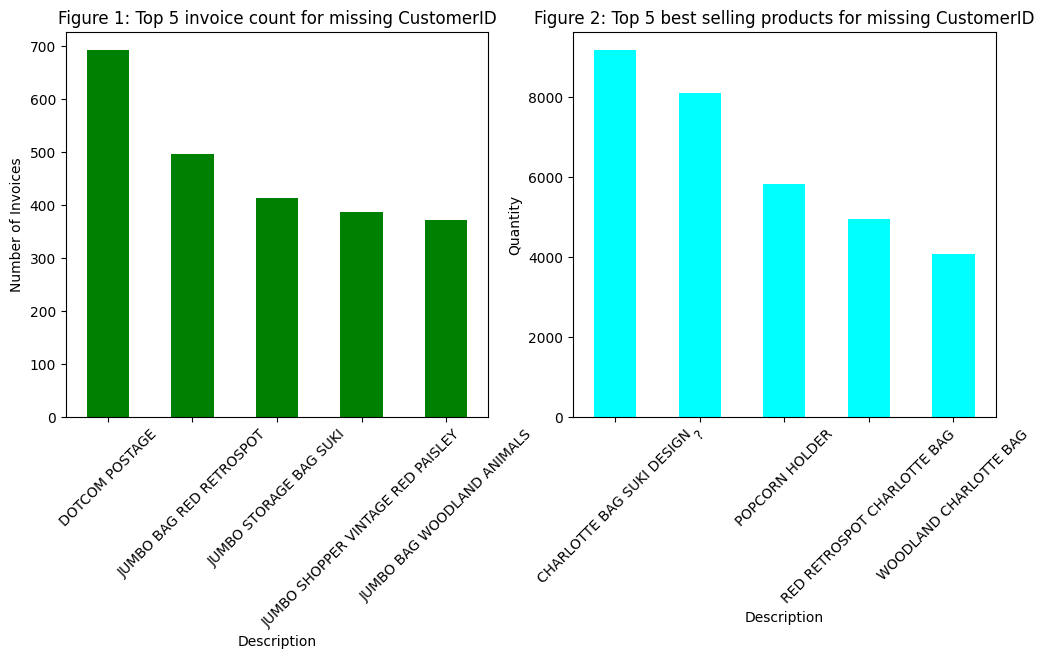

In [262]:
fig, ax=plt.subplots(1,2, figsize=(12,5))
CustomerID_NaN['Description'].value_counts().sort_values(ascending=False).head().plot(kind='bar', ax=ax[0], color='green')
ax[0].set_title("Figure 1: Top 5 invoice count for missing CustomerID")
ax[0].set_xlabel("Description")
ax[0].set_ylabel("Number of Invoices")
ax[0].tick_params(axis='x', rotation=45)  # ✅ 精準控制 ax[0]

Description_Quantity.head().plot(kind='bar', ax=ax[1], color='cyan')
ax[1].set_title('Figure 2: Top 5 best selling products for missing CustomerID')
ax[1].set_xlabel('Description')
ax[1].set_ylabel('Quantity')
ax[1].tick_params(axis='x', rotation=45)  # ✅ 精準控制 ax[1]
plt.show()

Obeservation 1: When switching from counting invoice to quantity the top 5 laterally changed

Observation 2: JUMBO no longer seats in the top 5

action 1: Compare the percentage occupied by Jumbo agains the top 5

In [263]:
print('JUMBO brand family against Top1 in terms of quantity')
tp1=str(Description_Quantity.index[0])
Quantity_of_tp1=Description_Quantity[tp1]
print(f"The percentile of {tp1} against the total quantity :{(Quantity_of_tp1/Description_Quantity.sum())*100}")

jumbo_quantity=Description_Quantity[Description_Quantity.index.str.contains('JUMBO')].sum()
print(f"The percentile of JUMBO brand family against the total quantity: {jumbo_quantity/CustomerID_NaN['Quantity'].sum()*100}")
No_Jumbo_records=len(CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')])


print(f'The percentage of number of JUMBO products {No_Jumbo_records/len(CustomerID_NaN)*100}')


JUMBO brand family against Top1 in terms of quantity
The percentile of CHARLOTTE BAG SUKI DESIGN against the total quantity :2.054233372730203
The percentile of JUMBO brand family against the total quantity: 5.066317812232021
The percentage of number of JUMBO products 4.0499703807017156


Observation 1: JUMBO brand family is still occupies higher amount of quantity then CHARLOTTE BAG SUKI DESIGN

Obeservation 2: The percentage of JUMBO family rises when using quantity.

In [264]:
jumbo_quantity=CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')]['Quantity'].sum()
print(f"The percentile of jumbo against the total number of customerIDs: {jumbo_quantity/CustomerID_NaN['Quantity'].sum()*100}")



The percentile of jumbo against the total number of customerIDs: 5.066317812232021


In [265]:
#Std of quantity
print(f'The mean, median and the standard deviation of the quantity of each product')
print(f'The median: {Description_Quantity.mean()}')
print(f'The mean: {Description_Quantity.median()}')
print(f'The standard deviation {Description_Quantity.std()}')
print()
print('_'*100)
print(f'The mean, median and standard deviation of number of records in each product/ description')
print(f'The mean: {CustomerID_NaN['Description'].value_counts().mean()}')
print(f'The median: {CustomerID_NaN['Description'].value_counts().median()}')
print(f'The standard deviation {CustomerID_NaN['Description'].value_counts().std()}')


The mean, median and the standard deviation of the quantity of each product
The median: 130.51007887817704
The mean: 42.0
The standard deviation 358.0369988138944

____________________________________________________________________________________________________
The mean, median and standard deviation of number of records in each product/ description
The mean: 38.786736780601814
The median: 22.0
The standard deviation 50.08958169698712


Observation 1: quantity has a left skewed behaviour that records do not have might be due to pullings of outliers on the lower limit side.

OBeservation 2: quantity has huge std because of scattered price setting

action: Identify outliers and decide whether to clean or not



#### Description sheet

In [266]:
#The filtering out the missing description
Description_NaN=df_clean[df_clean['Description'].isna()]

In [267]:
#Investigating whether description NaN records are the subsets of CustomerID NaNs
Description_NaN.isna().sum()

InvoiceNo        0
StockCode        0
Description    592
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     592
Country          0
Month            0
Revenue          0
dtype: int64

Obeservation 1: Descriptions NaNs are the subset of CustomerID as all descriptions have CustomerID as NaN

Action 2: Compare line chart of missing descriptions and customerID to find their relations

In [272]:
print(f'The number of description NaN records is zero :{len(Description_NaN[Description_NaN['UnitPrice']==0.0])}')

The number of description NaN records is zero :592


In [268]:
free_products=df_clean[(~df_clean['Description'].isna()) & (df_clean['UnitPrice']==0.0)]
free_products_name=free_products['Description'].unique().tolist()
free_products_name[0:10]

['amazon',
 'ROUND CAKE TIN VINTAGE GREEN',
 'CREAM SWEETHEART LETTER RACK',
 'ZINC WILLIE WINKIE  CANDLE STICK',
 'BOX OF 24 COCKTAIL PARASOLS',
 'DOORMAT ENGLISH ROSE ',
 'DOORMAT 3 SMILEY CATS',
 'GREEN REGENCY TEACUP AND SAUCER',
 'FRENCH BLUE METAL DOOR SIGN 7',
 'FRENCH BLUE METAL DOOR SIGN 5']

find what are the free products

In [269]:
print(free_products['Description'].str.isupper().value_counts())

Description
True     404
False    183
Name: count, dtype: int64


In [270]:

strange = free_products[free_products['Description'].str.islower()]
print(strange['Description'].value_counts().head(20))

Description
check                                  39
found                                  25
adjustment                             14
amazon                                  8
had been put aside                      5
dotcom                                  4
mailout                                 3
returned                                2
test                                    2
taig adjust                             2
amazon sales                            1
wrongly sold (22719) barcode            1
rcvd be air temp fix for dotcom sit     1
did  a credit  and did not tick ret     1
mailout                                 1
on cargo order                          1
to push order througha s stock was      1
came coded as 20713                     1
alan hodge cant mamage this section     1
allocate stock for dotcom orders ta     1
Name: count, dtype: int64


New observation: Status, e-commerce, adjustment and dotccom are still here

Obeservation: The free product descriptions that are not in capital are often associated with status, e-commerce type.

Action 1: Categorize them and assign to a new column named a [Is Operational] column.

In [ ]:

operational = [
    'check',           
    'damages',         
    'damaged',         
    'found',           
    'thrown away',     
    'adjustment',      
    'reverse',         
    'amazon',          
    'amazon sales',
    'ebay',            
    'wet',             
    'missing',        
    'test',            
    'smashed',       
    'mailout',         
    'counted',         
    'returned',        
    'put aside',      
    'on cargo',        
    'allocate stock',  
    'push order',     
    'coded as',        
    'credit',          
    'taig',            
    'alan hodge',      
    'dotcom',          
]

# 官網套裝銷售 → 保留（有效交易，只是沒有正式商品名）
dotcom_sale = [
    'sold as set on dotcom',  # 官網套裝銷售，真實交易
]

In [ ]:
# 3行中文計劃：
# 目標：把這些操作備註行單獨標記，不要 fill，不要刪
# 方法：建一個 flag 欄 'is_operational'
# 結果：分析時可以直接過濾掉

df_clean['is_operational'] = df_clean['Description'].str.lower().str.contains(
    '|'.join(operational), na=False
)

print(df['is_operational'].value_counts())

is_operational
False    540395
True       1514
Name: count, dtype: int64


In [271]:
free_products[free_products['Description'].str.isupper()]['Description']

9302             ROUND CAKE TIN VINTAGE GREEN
14335            CREAM SWEETHEART LETTER RACK
14336        ZINC WILLIE WINKIE  CANDLE STICK
14337             BOX OF 24 COCKTAIL PARASOLS
14338                   DOORMAT ENGLISH ROSE 
                         ...                 
503634                                 AMAZON
519355                                 AMAZON
521408    FRIDGE MAGNETS LES ENFANTS ASSORTED
521417               CLASSIC GLASS COOKIE JAR
521436                         DOTCOM POSTAGE
Name: Description, Length: 404, dtype: str

Observation: Operational type descriptions can still be capital

Action: Categorize them and assign to a new column named a [Is Operational] column.

Text(619.9949494949494, 0.5, 'Number of Records')

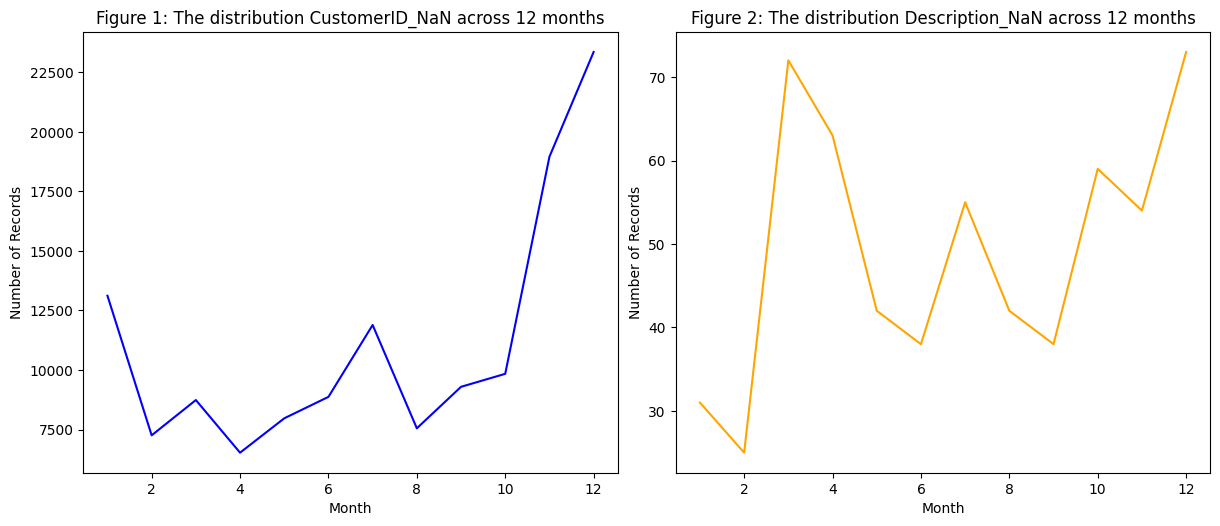

In [273]:
fig,ax=plt.subplots(1,2,figsize=(12, 5))
plt.tight_layout()
CustomerID_NaN['Month'].value_counts().sort_index().plot(kind='line', color='blue', ax=ax[0])
ax[0].set_title("Figure 1: The distribution CustomerID_NaN across 12 months")
ax[0].set_xlabel("Month")
ax[0].set_ylabel("Number of Records")

Description_NaN['Month'].value_counts().sort_index().plot(kind='line', color='orange', ax=ax[1])
ax[1].set_title("Figure 2: The distribution Description_NaN across 12 months")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Number of Records")

Obeservation 1: Strong trend of increasing missing records are spotted from october to december (Fig 1).


Obeservation 2: (Fig 2) There are two strong bumps in april and july

Obeservation 3: (Figure 1 & 2) have no relationships.

action: Scatter plot to prove whether the claim of observation 3 is correct or not


**Self notes: However the dataset start from 2010 december it would added to 2011 december which masks the number of customers in december (Advanced data question)**

# 02 Transformation

# 03 Analyse

# 04 Insight and Conclusion